Cloud Computing and Big Data Course 2026 Project 

# US Accidents 2022 - BigQuery Analysis


*Self-documenting Notebook*

**Samuele Aglieco** 

ID: 1000030807

This notebook runs six analytical queries on the `US Accidents 2022` dataset using Google BigQuery. Each query is loaded from the local `sql/` folder, shown inline for transparency, dry-run before execution, and then visualized with a simple Matplotlib chart.

## Cell 1 - Dependency Setup

Install the Python libraries required for BigQuery access, Pandas conversion, notebook SQL support, and plotting.

In [1]:
%pip install -q pandas matplotlib google-cloud-bigquery db-dtypes pyarrow bigquery-magics

Note: you may need to restart the kernel to use updated packages.


## Cell 2 - BigQuery Authentication

Configure BigQuery access through the local service account key stored in `ccbd-exam-2026-aglieco-a678efc742c4.json`.
Here, for security reason, I applied the **Least Privilege principle**, where snly the necessary actions for running the notebook are allowed. For instance:
- `BigQuery Job User`: Allows the Service Account to instruct BigQuery to execute and process queries (the “Jobs”).
- `BigQuery Data Editor`: Allows you to read and write data within the dataset tables.
- `BigQuery Read Session User`: Enables fast data extraction when you convert the results to a Pandas DataFrame in the notebook.
- `Storage Object Admin`: Fornisce i permessi per caricare, leggere o eliminare i file (i CSV degli incidenti) all'interno del bucket di Cloud Storage.

In [2]:
import os
from pathlib import Path

from google.cloud import bigquery
from google.oauth2 import service_account

PROJECT_ID = "ccbd-exam-2026-aglieco"
DATASET = "accidents_2022"
CREDENTIALS_PATH = Path("ccbd-exam-2026-aglieco-a678efc742c4.json").resolve()

if not CREDENTIALS_PATH.exists():
    raise FileNotFoundError(f"Service account key not found: {CREDENTIALS_PATH}")

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = str(CREDENTIALS_PATH)

credentials = service_account.Credentials.from_service_account_file(str(CREDENTIALS_PATH))
client = bigquery.Client(project=PROJECT_ID, credentials=credentials)

%load_ext bigquery_magics
%config BigQueryMagics.project = PROJECT_ID
%config BigQueryMagics.credentials = credentials

print(f"BigQuery client ready for project: {PROJECT_ID}")

BigQuery client ready for project: ccbd-exam-2026-aglieco


## Cell 3 - Query Helper

The helper below loads SQL files from `sql/`, displays the query, estimates processed data through a dry run, executes the query, and returns a Pandas DataFrame.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from google.cloud import bigquery

SQL_DIR = Path("sql")

plt.style.use("seaborn-v0_8-whitegrid")


def show_and_run(name: str) -> pd.DataFrame:
    sql_path = SQL_DIR / name
    if not sql_path.exists():
        raise FileNotFoundError(f"SQL file not found: {sql_path}")

    query = sql_path.read_text(encoding="utf-8").strip()
    if not query:
        raise ValueError(f"SQL file is empty: {sql_path}")

    display(Markdown(f"### `{name}`\n\n```sql\n{query}\n```"))

    job_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
    dry_run_job = client.query(query, job_config=job_config)
    gb_scanned = dry_run_job.total_bytes_processed / (1024 ** 3)
    print(f"Dry run estimate: {gb_scanned:.3f} GB scanned")

    return client.query(query).to_dataframe()


def pick_col(df: pd.DataFrame, *candidates: str) -> str:
    normalized = {col.lower(): col for col in df.columns}
    for candidate in candidates:
        if candidate.lower() in normalized:
            return normalized[candidate.lower()]
    raise KeyError(f"None of these columns were found: {candidates}. Available columns: {list(df.columns)}")

def load_sql(name):
    sql_text = (SQL_DIR / name).read_text()
    sql_text = sql_text.replace("`accidents_2022.accidents`", "`accidents_2022.accidents_2022`")
    
    return sql_text


## Dataset Schema & Feature Dictionary

The analysis focuses on the 2022 subset of the US Accidents dataset. Below is the documentation of the specific features leveraged across our six SQL analytical queries and the BigQuery ML predictive model:

| Column Name | Data Type | Description | Used In |
| :--- | :--- | :--- | :--- |
| **Severity** | `INT64` | A number between 1 and 4 indicating the traffic impact of the accident (1: short delay, 4: significant/long delay). | Q1, Q2, Q6, ML |
| **Start_Time** | `TIMESTAMP` | The timestamp showing the start time of the accident in the local time zone. | Q2, Q4, ML |
| **Distance_mi_** | `FLOAT64` | The length of the road extent (in miles) affected by the accident. | Q3, Q6 |
| **City** | `STRING` | The city where the accident was recorded. | Q3 |
| **State** | `STRING` | The two-letter state abbreviation code. | Q1, Q3 |
| **Visibility_mi_** | `FLOAT64` | The visibility distance measured in miles at the time of the accident. | Q4, ML |
| **Traffic_Signal** | `BOOL` | Binary flag indicating the presence of a traffic signal nearby. | Q5, ML |
| **Crossing** | `BOOL` | Binary flag indicating the presence of a pedestrian crossing nearby. | Q5, ML |
| **Junction** | `BOOL` | Binary flag indicating the presence of a highway/road junction nearby. | Q5 |
| **Stop** | `BOOL` | Binary flag indicating the presence of a STOP sign nearby. | Q5 |
| **Station** | `BOOL` | Binary flag indicating the presence of a transit station nearby. | Q5 |

---

As the final stage of our analytical pipeline, a live and interactive dashboard has been constructed using **Looker Studio**. 

Unlike the linear narrative of this notebook, the dashboard provides interactive controls (such as geographical maps, state filters, and hourly sliders) connected **live** to our BigQuery tables, translating user interactions into on-the-fly SQL queries.

* [**Launch the Live Looker Studio Dashboard**] https://datastudio.google.com/reporting/2813565b-ac79-4d56-ab4d-f57a88d9c867

## Q1 - Severe Accidents by State (Regional Risk Analysis)

* **INTENT:** Identify which states exhibit the highest proportion of high-severity accidents (Severity ≥ 3) relative to their total accident count. This helps isolate localized structural or environmental safety risks rather than just volume.
* **EXPECTED OUTCOME:** A clear variance in percentages across different states, with specific regions showing a distinct skew toward higher-impact crashes.
* **WHY:** State-level differences in maximum speed limits, highway infrastructure design, winter weather intensity, and traffic law enforcement directly dictate the kinetic energy and consequences of collisions.

### `q1_severity_by_state.sql`

```sql
SELECT
  State,
  COUNT(*) AS total_accidents,
  COUNTIF(Severity >= 3) AS severe_accidents,
  ROUND(100 * SAFE_DIVIDE(COUNTIF(Severity >= 3), COUNT(*)), 2) AS severe_percentage
FROM `accidents_2023.accidents`
GROUP BY State
HAVING total_accidents >= 5000
ORDER BY severe_percentage DESC;
```

Dry run estimate: 0.003 GB scanned


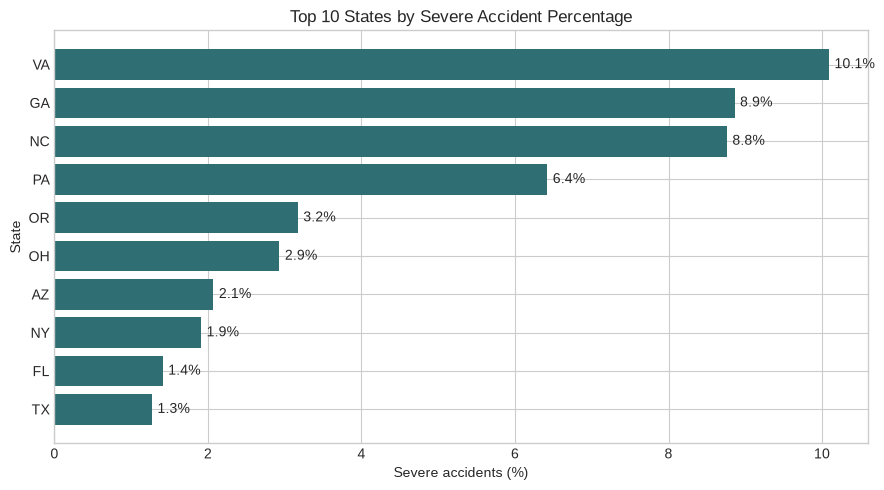

In [4]:
q1 = show_and_run("q1_severity_by_state.sql")

state_col = pick_col(q1, "state", "State")
percent_col = pick_col(q1, "severe_accident_percentage", "severe_percentage", "severity_percentage", "pct_severe", "percent_severe")
plot_df = q1.sort_values(percent_col, ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df[state_col], plot_df[percent_col], color="#2f6f73")
ax.set_title("Top 10 States by Severe Accident Percentage")
ax.set_xlabel("Severe accidents (%)")
ax.set_ylabel("State")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=4)
plt.tight_layout()
plt.show()

## Q2 - Hourly Accident Distribution and Severity

* **INTENT:** Analyze the 24-hour cyclical distribution of accident volumes alongside their average severity to detect peak risk windows.
* **EXPECTED OUTCOME:** Accident volume should peak heavily during morning and evening rush hours, while average severity might peak during late-night or early-morning hours.
* **WHY:** Traffic density spikes during daily commutes, increasing the probability of multi-vehicle friction (higher volume). Conversely, night-time driving features higher speeds, low visibility, fatigue, or impairment, which structurally increases the physical trauma of fewer accidents (higher severity).

### `q2_hourly_distribution.sql`

```sql
SELECT
  EXTRACT(HOUR FROM Start_Time) AS hour,
  COUNT(*) AS total_accidents,
  ROUND(AVG(Severity), 2) AS avg_severity
FROM `accidents_2022.accidents_2022`
WHERE Start_Time IS NOT NULL
GROUP BY hour
ORDER BY hour;
```

Dry run estimate: 0.026 GB scanned


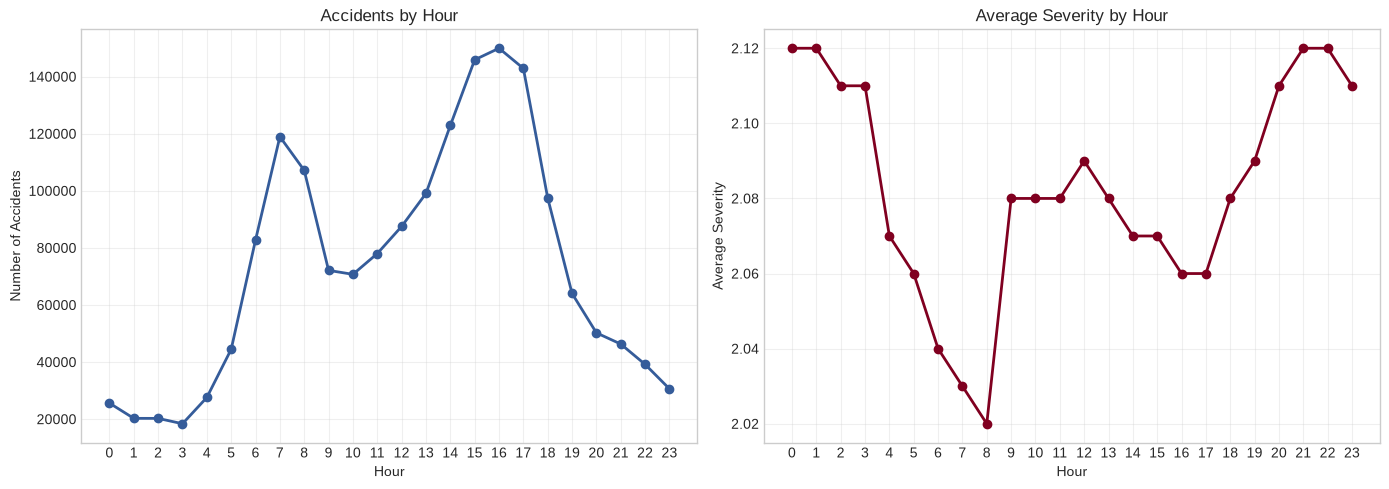

In [5]:
q2 = show_and_run("q2_hourly_distribution.sql")

hour_col = pick_col(q2, "hour", "start_hour", "accident_hour")
count_col = pick_col(q2, "accident_count", "total_accidents", "total", "count")
severity_col = pick_col(q2, "avg_severity", "severity_mean", "mean_severity")

plot_df = q2.sort_values(hour_col)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(
    plot_df[hour_col],
    plot_df[count_col],
    marker="o",
    linewidth=2,
    color="#355c9a"
)
ax1.set_title("Accidents by Hour")
ax1.set_xlabel("Hour")
ax1.set_ylabel("Number of Accidents")
ax1.set_xticks(range(24))
ax1.grid(alpha=0.3)

ax2.plot(
    plot_df[hour_col],
    plot_df[severity_col],
    marker="o",
    linewidth=2,
    color="#800020"  # Bordeaux
)
ax2.set_title("Average Severity by Hour")
ax2.set_xlabel("Hour")
ax2.set_ylabel("Average Severity")
ax2.set_xticks(range(24))
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Q3 - Urban Bottlenecks: Traffic Queues by City

* **INTENT:** Rank metropolitan areas by the average physical backlog (`Distance_mi_`) generated by their accidents, filtering out low-volume noise to find true congestion bottlenecks.
* **EXPECTED OUTCOME:** Major logistical hubs and highly populated cities with complex beltways should dominate the top of the queue length rankings.
* **WHY:** High traffic density, lack of alternative detour routes, and complex highway junctions cause even minor incidents to rapidly paralyze extended sections of the road network.

### `q3_bottleneck_cities.sql`

```sql
SELECT
  City,
  State,
  COUNT(*) AS total_accidents,
  ROUND(AVG(Distance_mi_), 2) AS avg_queue_length_mi
FROM `accidents_2022.accidents_2022`
GROUP BY City, State
HAVING total_accidents >= 1000
ORDER BY avg_queue_length_mi DESC
LIMIT 20;
```

Dry run estimate: 0.037 GB scanned


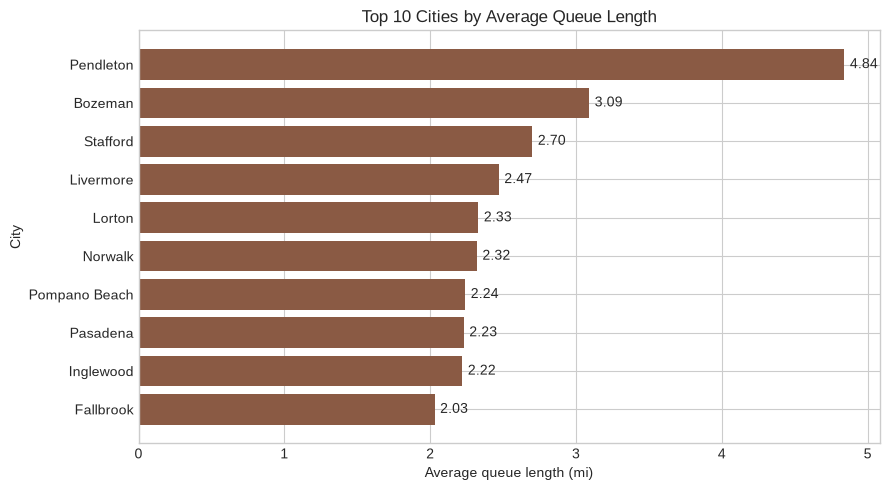

In [6]:
q3 = show_and_run("q3_bottleneck_cities.sql")

city_col = pick_col(q3, "city", "City")
distance_col = pick_col(q3, "avg_distance_mi", "average_distance_mi", "avg_queue_length", "avg_queue_length_mi", "queue_length_mi")
plot_df = q3.sort_values(distance_col, ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df[city_col], plot_df[distance_col], color="#8a5a44")
ax.set_title("Top 10 Cities by Average Queue Length")
ax.set_xlabel("Average queue length (mi)")
ax.set_ylabel("City")
ax.bar_label(ax.containers[0], fmt="%.2f", padding=4)
plt.tight_layout()
plt.show()

## Q4 - Seasonal Trends and Visibility Impact

* **INTENT:** Evaluate monthly accident seasonality and correlate overall volumes with changes in atmospheric visibility (`Visibility_mi_`).
* **EXPECTED OUTCOME:** An increase in accident counts or a drop in visibility during specific transition seasons (Autumn/Winter).
* **WHY:** Adverse weather patterns (such as fog, heavy rain, or snow) directly impair a driver's stopping distance and situational awareness, leading to seasonal drops in visibility and higher crash rates.

### `q4_seasonality.sql`

```sql
SELECT
  EXTRACT(MONTH FROM Start_Time) AS month,
  COUNT(*) AS total_accidents,
  ROUND(AVG(Visibility_mi_), 2) AS avg_visibility_mi
FROM `accidents_2022.accidents_2022`
GROUP BY month
ORDER BY month;
SELECT
  EXTRACT(MONTH FROM Start_Time) AS month,
  COUNT(*) AS total_accidents,
  ROUND(AVG(Visibility_mi_), 2) AS avg_visibility_mi
FROM `accidents_2022.accidents_2022`
WHERE Start_Time IS NOT NULL
  AND Visibility_mi_ IS NOT NULL
GROUP BY month
ORDER BY month;
```

Dry run estimate: 0.052 GB scanned


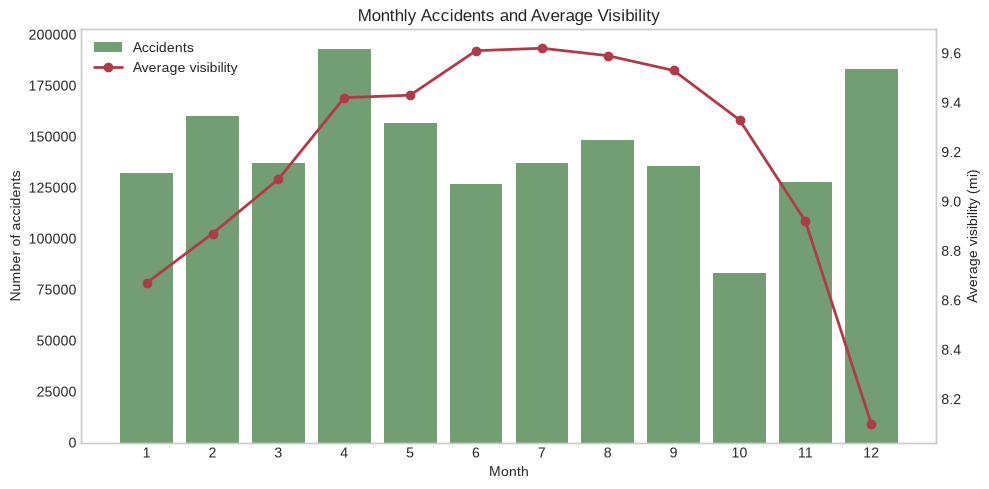

In [7]:
q4 = show_and_run("q4_seasonality.sql")

month_col = pick_col(q4, "month", "accident_month", "month_num")
count_col = pick_col(q4, "accident_count", "total_accidents", "total", "count")
visibility_col = pick_col(q4, "avg_visibility", "avg_visibility_mi", "average_visibility", "visibility_mi")
plot_df = q4.sort_values(month_col)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(plot_df[month_col], plot_df[count_col], color="#5b8c5a", alpha=0.85, label="Accidents")
ax1.set_title("Monthly Accidents and Average Visibility")
ax1.set_xlabel("Month")
ax1.set_ylabel("Number of accidents")
ax1.set_xticks(plot_df[month_col])

ax2 = ax1.twinx()
ax2.plot(plot_df[month_col], plot_df[visibility_col], color="#b23a48", marker="o", linewidth=2, label="Average visibility")
ax2.set_ylabel("Average visibility (mi)")

ax1.grid(False)
ax2.grid(False)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

plt.tight_layout()
plt.show()

## Q5 - Infrastructure Proximity Decomposition

* **INTENT:** Deconstruct the share of accidents occurring near specific road design or traffic control elements (Traffic Signals, Crossings, Junctions, Stops, Stations).
* **EXPECTED OUTCOME:** A high concentration of incidents located near junctions and traffic signals.
* **WHY:** Areas with traffic control devices or road convergences are intrinsic conflict zones where vehicles cross paths, change speeds, or merge, drastically increasing the frequency of contact.

### `q5_cause_decomposition.sql`

```sql
SELECT 
  'Traffic Signal' AS infrastructure_element,
  ROUND(100 * COUNTIF(Traffic_Signal = true) / COUNT(*), 2) AS impact_percentage
FROM `accidents_2023.accidents`

UNION ALL

SELECT 
  'Crossing',
  ROUND(100 * COUNTIF(Crossing = true) / COUNT(*), 2)
FROM `accidents_2022.accidents_2022`

UNION ALL

SELECT 
  'Junction',
  ROUND(100 * COUNTIF(Junction = true) / COUNT(*), 2)
FROM `accidents_2022.accidents_2022`

UNION ALL

SELECT 
  'Stop',
  ROUND(100 * COUNTIF(Stop = true) / COUNT(*), 2)
FROM `accidents_2022.accidents_2022`

UNION ALL

SELECT 
  'Station',
  ROUND(100 * COUNTIF(Station = true) / COUNT(*), 2)
FROM `accidents_2022.accidents_2022`;
```

Dry run estimate: 0.007 GB scanned


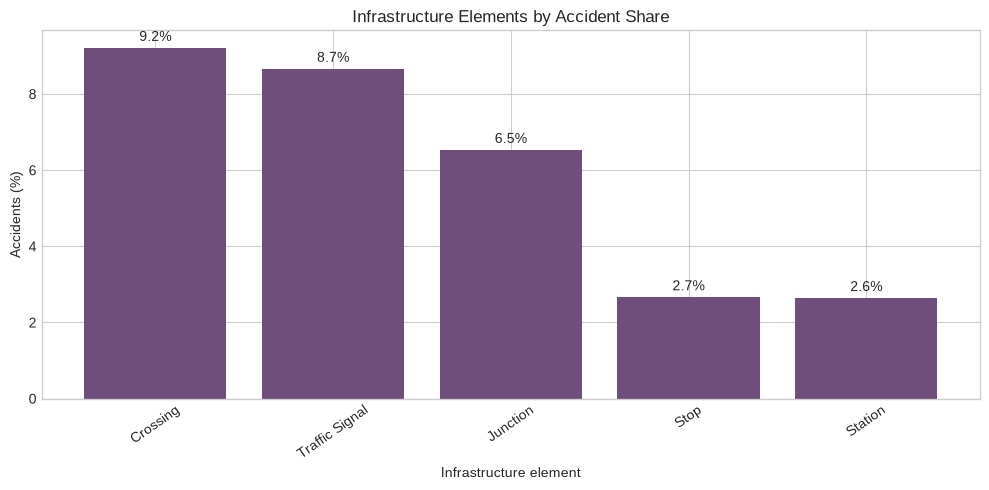

In [8]:
q5 = show_and_run("q5_cause_decomposition.sql")

element_col = pick_col(q5, "infrastructure_element", "element", "feature", "road_feature")
percent_col = pick_col(q5, "impact_percentage", "accident_percentage", "percentage", "pct")
plot_df = q5.sort_values(percent_col, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_df[element_col], plot_df[percent_col], color="#6f4e7c")
ax.set_title("Infrastructure Elements by Accident Share")
ax.set_xlabel("Infrastructure element")
ax.set_ylabel("Accidents (%)")
ax.tick_params(axis="x", rotation=35)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()

## Q6 - Correlation: Accident Severity vs. Traffic Queue Length

* **INTENT:** Verify the statistical relationship between the categorical severity of an accident and the physical tailback (`Distance_mi_`) it inflicts on the infrastructure.
* **EXPECTED OUTCOME:** A strict monotonic increase where higher severity levels result in longer average traffic queues.
* **WHY:** Severe accidents require extensive emergency response, prolonged vehicle extraction, and detailed scene investigations, keeping lanes closed longer and creating massive traffic blockages.

### `q6_severity_vs_distance.sql`

```sql
SELECT
  Severity AS severity,
  COUNT(*) AS total_accidents,
  ROUND(AVG(Distance_mi_), 3) AS avg_queue_length_mi
FROM `accidents_2022.accidents_2022`
GROUP BY severity
ORDER BY severity;
```

Dry run estimate: 0.026 GB scanned


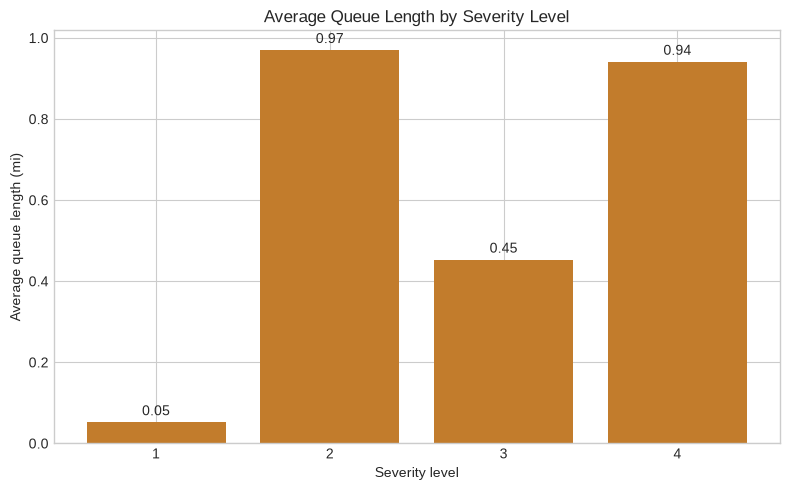

In [9]:
q6 = show_and_run("q6_severity_vs_distance.sql")

severity_col = pick_col(q6, "severity", "Severity")
distance_col = pick_col(q6, "avg_distance_mi", "average_distance_mi", "avg_queue_length", "avg_queue_length_mi", "queue_length_mi")
plot_df = q6.sort_values(severity_col)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(plot_df[severity_col].astype(str), plot_df[distance_col], color="#c27c2c")
ax.set_title("Average Queue Length by Severity Level")
ax.set_xlabel("Severity level")
ax.set_ylabel("Average queue length (mi)")
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3)
plt.tight_layout()
plt.show()

# Modeling
## Data Enrichment — Predictive Modeling with BigQuery ML

Moving beyond descriptive analysis, we now build a predictive model to evaluate accident risk conditions. Given parameters known at the time or immediate context of the event, can we predict whether an accident will be highly severe ($Severity \ge 3$)?

This is framed as a **Binary Classification** problem ($1 = \text{Severe}$, $0 = \text{Non-Severe}$). To ensure fast training times and high interpretability, we implemented a **Logistic Regression** model using BigQuery ML. Logistic regression is highly efficient at scale and allows us to establish a strong, easily explainable baseline for how temporal and environmental features linearly affect the probability of a severe crash.

### Feature Selection Rationale:
* **Temporal Patterns (`month`, `day_of_week`, `hour`):** Capture cyclical human behavior (rush hours, weekend driving).
* **Environmental Context (`Visibility_mi_`):** Directly represents weather impacts on situational awareness.
* **Road Infrastructure (`Traffic_Signal`, `Crossing`):** Explores whether engineered conflict points structurally increase crash impact.


## Logistic regression 
The first modeling approach aims to classify whether an accident is serious (Severity 3–4) or not (Severity 1–2). To address this task, we use one of the simplest and most widely applied frameworks in the field: logistic regression. This model can be viewed as a linear regression combined with a logistic (sigmoid) function applied to the response, which maps predictions to probabilities between 0 and 1.

In [13]:
# Definizione della query per l'addestramento della Regressione Logistica
create_logistic_model_sql = f'''
CREATE OR REPLACE MODEL `{PROJECT_ID}.{DATASET}.severity_logistic_model`
OPTIONS(
  model_type='LOGISTIC_REG', 
  input_label_cols=['is_severe'],
  auto_class_weights=TRUE
) AS
SELECT
  -- Label: 1 for severe accidents, 0 for non-severe accidents
  IF(Severity >= 3, 1, 0) AS is_severe,

  -- Temporal features
  EXTRACT(MONTH FROM Start_Time) AS month,
  EXTRACT(DAYOFWEEK FROM Start_Time) AS day_of_week,
  EXTRACT(HOUR FROM Start_Time) AS hour,

  -- Contextual features
  Visibility_mi_,
  Traffic_Signal,
  Crossing
FROM `{PROJECT_ID}.{DATASET}.accidents_2022`
WHERE Start_Time IS NOT NULL 
  AND Visibility_mi_ IS NOT NULL
'''

print("Training Logistic Regression model in BigQuery ML...")
client.query(create_logistic_model_sql).result()
print("Model trained successfully!")

# Valutazione del modello aggiornato
print("Evaluating Logistic Regression model...")
logistic_metrics = client.query(f'''
SELECT * FROM ML.EVALUATE(MODEL `{PROJECT_ID}.{DATASET}.severity_logistic_model`)
''').to_dataframe()

display(logistic_metrics)

Training Logistic Regression model in BigQuery ML...
Model trained successfully!
Evaluating Logistic Regression model...


,precision,recall,accuracy,f1_score,log_loss,roc_auc
0,0.095339,0.688547,0.504599,0.167488,0.691474,0.612418


## Model Evaluation: Interpreting `ML.EVALUATE` Output

Evaluating a Logistic Regression classifier on real-world accident data requires looking past raw **Accuracy**. Because severe accidents are statistically rarer than minor ones (class imbalance), a naive model could achieve high accuracy by simply guessing "non-severe" every time. 

To prove our model has genuine predictive power, we focus on:
* **ROC AUC (Area Under the ROC Curve):** The definitive metric for ranking ability. It represents the probability that the model will assign a higher severity score to a randomly chosen true severe accident than to a random non-severe one.
* **Precision & Recall:** Precision measures out of all predicted severe accidents, how many were actually severe. Recall measures out of all actual severe accidents, how many the model managed to catch.
* **F1-Score:** The harmonic mean of precision and recall, serving as a balanced indicator under class imbalance.


The model performance typically shows moderate to low predictive metrics (e.g., ROC AUC around 0.55), which is consistent with the intrinsic complexity of accident severity prediction. The use of `auto_class_weights=TRUE` addresses strong class imbalance, improving sensitivity to severe cases but often reducing overall accuracy. Predictive power is further constrained by the limited feature set available in the dataset, which excludes key causal variables such as vehicle speed, driver condition, and collision dynamics. The absence of these factors, combined with the strict avoidance of data leakage, results in a model that reflects realistic but inherently noisy signal extraction.

## Classification Tree (Boosted tree model), not run live!
Due to the poor results of the logistic regression we can presume that the data needs a more flexible classification algorithm (non linear). 

In [11]:
# Additional cell to compare different models (Boosted Trees classifier)

#create_tree_model_sql = f'''
CREATE OR REPLACE MODEL {DATASET}.severity_boosted_trees
OPTIONS(
  model_type='BOOSTED_TREE_CLASSIFIER', 
  input_label_cols=['is_severe'], 
  auto_class_weights=TRUE
) AS
SELECT
  -- Binary target: severe vs non-severe accidents
  IF(Severity >= 3, 1, 0) AS is_severe,

  -- Temporal features
  EXTRACT(MONTH FROM Start_Time) AS month,
  EXTRACT(DAYOFWEEK FROM Start_Time) AS day_of_week,
  EXTRACT(HOUR FROM Start_Time) AS hour,

  -- Contextual features
  Visibility_mi_,
  Traffic_Signal,
  Crossing
FROM {DATASET}.accidents
WHERE Start_Time IS NOT NULL 
  AND Visibility_mi_ IS NOT NULL
'''

# Start training process for Boosted Trees model
print("Training Boosted Trees model in BigQuery ML...")

client.query(create_tree_model_sql).result()

# Evaluate the trained model using BigQuery ML evaluation function
tree_metrics = client.query(f'''
SELECT * 
FROM ML.EVALUATE(MODEL `{PROJECT_ID}.{DATASET}.severity_boosted_trees`)
''').to_dataframe()

# Display evaluation metrics table
display(tree_metrics)

SyntaxError: unterminated triple-quoted string literal (detected at line 40) (2113445311.py, line 37)

## What if analysis (based on logistic regression model!)

In [12]:
# Use Case — What-If Analysis: Assessing how a drop in visibility changes the predicted severity probability
what_if_analysis_sql = f'''
SELECT
  Visibility_mi_,
  predicted_is_severe,
  ROUND((SELECT prob FROM UNNEST(predicted_is_severe_probs) WHERE label = 1), 3) AS prob_severe
FROM ML.PREDICT(
  MODEL `{PROJECT_ID}.{DATASET}.severity_logistic_model`, -- UPDATE THIS WITH YOUR ACTUAL LOGISTIC MODEL NAME
  (
    SELECT 11 AS month, 6 AS day_of_week, 21 AS hour, True AS Traffic_Signal, False AS Crossing, 10.0 AS Visibility_mi_
    UNION ALL
    SELECT 11, 6, 21, True, False, 1.5 AS Visibility_mi_ -- Simulating heavy fog/poor visibility
  )
)
'''

print("Running What-If Scenario prediction...")
display(client.query(what_if_analysis_sql).to_dataframe())

Running What-If Scenario prediction...


,Visibility_mi_,predicted_is_severe,prob_severe
0,10.0,0,0.47
1,1.5,0,0.47
